# 03 — Data quality verification

This notebook verifies the quality of the structured outputs created by `01_collection_inventory.ipynb`.

It checks the inventory tables for missing values, duplicate records,
invalid values, inconsistent formats, broken relationships between tables,
and other potential data-quality issues before further data preparation.

The purpose of this notebook is to identify and document quality problems.
It does not automatically correct the source data.

## 1. Dependencies and paths

Import the Python libraries required for the data-quality checks and define the location of the inventory files.

Run this notebook from the `notebooks/` folder, the same as `01_collection_inventory.ipynb` and `02_data_description.ipynb`.

The inventory directory is checked before continuing so that the notebook stops with a clear error if the required data has not yet been generated.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

INVENTORY_DIR = Path('../output/inventory').resolve()

if not INVENTORY_DIR.is_dir():
    raise FileNotFoundError(
        f'Inventory folder not found: {INVENTORY_DIR}. '
        'Run 01_collection_inventory.ipynb first.'
    )

print(f'Inventory folder: {INVENTORY_DIR}')

Inventory folder: /Users/fatimahabbasi/Downloads/DDD/output/inventory


## 2. Load the inventory tables

Load the three structured inventory tables used throughout the project:

- `documents.csv`: one row per unique PDF document.
- `metadata_observations.csv`: metadata values observed from different sources.
- `document_terms.csv`: keywords, themes, authors, or other supplied document terms.

The tables are loaded as strings so that the original stored values can be inspected before any conversions or corrections are made.

`document_id` is the common identifier used to connect records between the tables.

In [2]:
def load_csv(filename):
    path = INVENTORY_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')

    return pd.read_csv(
        path,
        dtype=str,
        keep_default_na=False,
        encoding='utf-8-sig'
    )


documents = load_csv('documents.csv')
observations = load_csv('metadata_observations.csv')
terms = load_csv('document_terms.csv')

print(f'Documents: {len(documents):,} rows')
print(f'Metadata observations: {len(observations):,} rows')
print(f'Document terms: {len(terms):,} rows')

Documents: 93 rows
Metadata observations: 311 rows
Document terms: 116 rows


## 3. Missing-value checks

Check each table for missing or empty values.

Because the inventory files are loaded with `keep_default_na=False`, empty fields are normally represented as empty strings rather than automatically converted to `NaN`.

The summary below therefore checks for both empty strings and missing values. A high number of missing values does not necessarily mean that the data is incorrect, but it can identify fields that require further review.

In [3]:
def missing_summary(df):
    missing = df.isna() | df.eq('')

    result = pd.DataFrame({
        'missing_count': missing.sum(),
        'missing_percentage': missing.mean() * 100
    })

    return result.sort_values(
        'missing_percentage',
        ascending=False
    )


print('DOCUMENTS')
display(missing_summary(documents))

print('METADATA OBSERVATIONS')
display(missing_summary(observations))

print('DOCUMENT TERMS')
display(missing_summary(terms))

DOCUMENTS


,missing_count,missing_percentage
publinova_url,93,100.00
scan_error,93,100.00
language,93,100.00
document_type,93,100.00
online_date,93,100.00
publication_date,93,100.00
publication_year,93,100.00
doi,93,100.00
title,93,100.00
review_notes,93,100.00


METADATA OBSERVATIONS


,missing_count,missing_percentage
document_id,0,0.00
field_name,0,0.00
observed_value,0,0.00
source_type,0,0.00
source_location,0,0.00
extraction_method,0,0.00
review_status,0,0.00


DOCUMENT TERMS


,missing_count,missing_percentage
document_id,0,0.00
term_type,0,0.00
term_value,0,0.00
source_type,0,0.00
position,0,0.00
review_status,0,0.00


## 4. Duplicate records

Check the inventory tables for completely duplicated rows.

Duplicate records can cause the same information to be counted more than once during later analysis. This check identifies exact row duplicates without removing them.

The `documents` table is also checked separately for duplicate `document_id` values because each unique document should have its own identifier.

In [4]:
for name, df in [
    ('documents', documents),
    ('observations', observations),
    ('terms', terms)
]:
    duplicates = df.duplicated().sum()

    print(
        f'{name}: {duplicates:,} completely duplicated rows'
    )

documents: 0 completely duplicated rows
observations: 0 completely duplicated rows
terms: 0 completely duplicated rows


In [5]:
duplicate_document_ids = documents[
    documents['document_id'].duplicated(keep=False)
]

print(
    f'Rows with duplicated document IDs: '
    f'{len(duplicate_document_ids):,}'
)

if not duplicate_document_ids.empty:
    display(
        duplicate_document_ids.sort_values('document_id')
    )

Rows with duplicated document IDs: 0


## 5. Document identifier quality

`document_id` is the common identifier connecting the documents, metadata observations, and document terms tables.

Missing identifiers can prevent records from being correctly linked between tables. This check counts rows where `document_id` is empty in each dataset.

In [6]:
for name, df in [
    ('documents', documents),
    ('observations', observations),
    ('terms', terms)
]:
    if 'document_id' in df.columns:
        missing_ids = df['document_id'].eq('').sum()

        print(
            f'{name}: {missing_ids:,} rows '
            'with missing document_id'
        )

documents: 0 rows with missing document_id
observations: 0 rows with missing document_id
terms: 0 rows with missing document_id


## 6. Referential integrity

Metadata observations and document terms should refer to documents that exist in the main `documents` table.

This check compares the `document_id` values in the related tables against the identifiers in `documents.csv`.

Records referring to an unknown document may indicate an incomplete inventory, an incorrect identifier, or a problem during data collection.

In [7]:
valid_document_ids = set(documents['document_id'])

unknown_observation_ids = observations[
    ~observations['document_id'].isin(valid_document_ids)
]

unknown_term_ids = terms[
    ~terms['document_id'].isin(valid_document_ids)
]

print(
    'Observations referencing unknown documents:',
    len(unknown_observation_ids)
)

print(
    'Terms referencing unknown documents:',
    len(unknown_term_ids)
)

if not unknown_observation_ids.empty:
    display(unknown_observation_ids)

if not unknown_term_ids.empty:
    display(unknown_term_ids)

Observations referencing unknown documents: 0
Terms referencing unknown documents: 0


## 7. Numeric field validity

Several document-level fields are expected to contain numeric values:

- `file_size_bytes`
- `page_count`
- `extracted_char_count`
- `pages_without_text`

This check tests whether non-empty values in these fields can be converted to numbers.

It also identifies negative values, because negative file sizes, page counts, extracted character counts, or pages without text would not represent valid document characteristics.

In [8]:
numeric_columns = [
    'file_size_bytes',
    'page_count',
    'extracted_char_count',
    'pages_without_text'
]

for col in numeric_columns:

    if col not in documents.columns:
        continue

    original = documents[col]

    numeric = pd.to_numeric(
        original,
        errors='coerce'
    )

    invalid = original.ne('') & numeric.isna()
    negative = numeric < 0

    print(f'\n{col}')
    print(
        f'Invalid numeric values: '
        f'{invalid.sum():,}'
    )
    print(
        f'Negative values: '
        f'{negative.sum():,}'
    )

    if invalid.any():
        display(
            documents.loc[
                invalid,
                ['document_id', col]
            ]
        )


file_size_bytes
Invalid numeric values: 0
Negative values: 0

page_count
Invalid numeric values: 0
Negative values: 0

extracted_char_count
Invalid numeric values: 0
Negative values: 0

pages_without_text
Invalid numeric values: 0
Negative values: 0


## 8. Page-count consistency

The `pages_without_text` field records how many pages in a PDF did not produce extracted text.

This number should not be greater than the document's total `page_count`.

Documents where `pages_without_text` is greater than `page_count` are therefore flagged as inconsistent and should be manually reviewed.

In [9]:
page_count = pd.to_numeric(
    documents['page_count'],
    errors='coerce'
)

pages_without_text = pd.to_numeric(
    documents['pages_without_text'],
    errors='coerce'
)

invalid_page_relationship = (
    pages_without_text > page_count
)

print(
    'Documents where pages_without_text '
    'is greater than page_count:',
    invalid_page_relationship.sum()
)

if invalid_page_relationship.any():
    display(
        documents.loc[
            invalid_page_relationship,
            [
                'document_id',
                'page_count',
                'pages_without_text'
            ]
        ]
    )

Documents where pages_without_text is greater than page_count: 0


## 9. Zero-value document checks

Some numeric values may be valid in format but still indicate a potential
data-quality problem.

A PDF with zero pages or zero file size may indicate an invalid or corrupted
document. A document with zero extracted characters may indicate that text
extraction was unsuccessful.

These values are therefore checked separately and reported for further review.

In [10]:
zero_checks = {}

for col in [
    'file_size_bytes',
    'page_count',
    'extracted_char_count'
]:
    numeric = pd.to_numeric(
        documents[col],
        errors='coerce'
    )

    zero_checks[col] = (numeric == 0).sum()

zero_summary = pd.Series(
    zero_checks,
    name='zero_values'
).to_frame()

display(zero_summary)

,zero_values
file_size_bytes,0
page_count,0
extracted_char_count,1


One document has zero extracted characters. The record is displayed below
to determine whether this corresponds to a document already classified as
having no extractable text.

In [11]:
zero_extracted_text = documents[
    pd.to_numeric(
        documents['extracted_char_count'],
        errors='coerce'
    ).eq(0)
]

display(
    zero_extracted_text[
        [
            'document_id',
            'file_name',
            'page_count',
            'extracted_char_count',
            'text_status'
        ]
    ]
)

,document_id,file_name,page_count,extracted_char_count,text_status
54,doc_c9cb81e6840debfe,055_jonge-zeeuwen-in-beweging.pdf,1,0,no_text


## 10. Publication-year validity

Check the reviewed publication years for invalid or implausible values.

Non-empty values that cannot be converted to numbers are identified as invalid.

Numeric years outside the expected range are also flagged for review. These values are not automatically corrected because an unusual value should be checked against the original document or metadata source first.

In [12]:
if 'publication_year' in documents.columns:

    year_text = documents['publication_year']

    years = pd.to_numeric(
        year_text,
        errors='coerce'
    )

    invalid_year = (
        year_text.ne('') &
        years.isna()
    )

    implausible_year = (
        years.notna() &
        (
            (years < 1800) |
            (years > 2100)
        )
    )

    print(
        f'Invalid publication years: '
        f'{invalid_year.sum():,}'
    )

    print(
        f'Implausible publication years: '
        f'{implausible_year.sum():,}'
    )

    if invalid_year.any():
        display(
            documents.loc[
                invalid_year,
                ['document_id', 'publication_year']
            ]
        )

    if implausible_year.any():
        display(
            documents.loc[
                implausible_year,
                ['document_id', 'publication_year']
            ]
        )

Invalid publication years: 0
Implausible publication years: 0


## 11. Categorical consistency

Categorical fields should use consistent labels so that equivalent values are not treated as separate categories.

This section displays the distinct values and their frequencies for selected document fields.

The output can reveal differences in spelling, capitalization, abbreviations, or empty values that may need to be standardized during data preparation.

In [13]:
categorical_columns = [
    'text_status',
    'metadata_review_status',
    'document_type',
    'language'
]

for col in categorical_columns:

    if col in documents.columns:

        print(f'\n{col.upper()}')

        display(
            documents[col]
            .replace('', '[EMPTY]')
            .value_counts(dropna=False)
            .rename('count')
            .to_frame()
        )


TEXT_STATUS


,count
text_status,
extractable,85
partial,7
no_text,1



METADATA_REVIEW_STATUS


,count
metadata_review_status,
unreviewed,93



DOCUMENT_TYPE


,count
document_type,
[EMPTY],93



LANGUAGE


,count
language,
[EMPTY],93


## 12. Whitespace consistency

Text values may contain accidental spaces before or after their actual content.

Leading or trailing whitespace can make otherwise identical values appear different during grouping, filtering, or comparison.

This check identifies columns containing values with unnecessary surrounding whitespace. The values are reported but are not automatically changed.

In [14]:
for name, df in [
    ('documents', documents),
    ('observations', observations),
    ('terms', terms)
]:

    problems = []

    for col in df.columns:

        values = df[col].astype(str)

        count = (
            values != values.str.strip()
        ).sum()

        if count:
            problems.append({
                'column': col,
                'rows_with_whitespace': count
            })

    print(f'\n{name.upper()}')

    if problems:
        display(pd.DataFrame(problems))
    else:
        print(
            'No leading or trailing '
            'whitespace found.'
        )


DOCUMENTS
No leading or trailing whitespace found.

OBSERVATIONS
No leading or trailing whitespace found.

TERMS
No leading or trailing whitespace found.


## 13. Important metadata completeness

The main documents table contains several reviewed metadata fields that are useful for later analysis, including title, DOI, publication information, document type, and language.

This check measures how many documents are missing values in these fields.

Missing metadata is not automatically considered an error because some information may genuinely be unavailable. The results instead identify fields where metadata coverage may require further review.

In [15]:
important_fields = [
    'title',
    'doi',
    'publication_year',
    'publication_date',
    'online_date',
    'document_type',
    'language'
]

results = []

for col in important_fields:

    if col in documents.columns:

        empty = documents[col].eq('').sum()

        results.append({
            'field': col,
            'empty_values': empty,
            'empty_percentage':
                empty / len(documents) * 100
                if len(documents) else 0
        })

display(pd.DataFrame(results))

,field,empty_values,empty_percentage
0,title,93,100.00
1,doi,93,100.00
2,publication_year,93,100.00
3,publication_date,93,100.00
4,online_date,93,100.00
5,document_type,93,100.00
6,language,93,100.00


## 14. Metadata observation quality

Although the reviewed metadata fields in `documents.csv` are currently
unpopulated, metadata candidates are available in
`metadata_observations.csv`.

This section examines the quality and coverage of those observations.
It checks for empty observed values and duplicate records and summarizes
which metadata fields have been observed across the document collection.

This distinction is important because missing reviewed metadata does not
necessarily mean that no metadata has been collected.

In [16]:
print(f'Total metadata observations: {len(observations):,}')

empty_observed_values = observations['observed_value'].eq('').sum()
duplicate_observations = observations.duplicated().sum()

print(f'Empty observed values: {empty_observed_values:,}')
print(f'Duplicate observation rows: {duplicate_observations:,}')

observation_fields = (
    observations['field_name']
    .value_counts()
    .rename('observations')
    .to_frame()
)

display(observation_fields)

Total metadata observations: 311
Empty observed values: 0
Duplicate observation rows: 0


,observations
field_name,
pdf_creation_date,93
title,65
author,62
doi,33
subject,26
pdf_keywords,21
online_date,11


In [17]:
observation_coverage = (
    observations
    .groupby('field_name')['document_id']
    .nunique()
    .sort_values(ascending=False)
    .rename('documents_with_observation')
    .to_frame()
)

observation_coverage['coverage_percentage'] = (
    observation_coverage['documents_with_observation']
    / len(documents)
    * 100
)

display(observation_coverage)

,documents_with_observation,coverage_percentage
field_name,,
pdf_creation_date,93,100.00
title,65,69.89
author,62,66.67
doi,33,35.48
subject,26,27.96
pdf_keywords,21,22.58
online_date,11,11.83


## 15. DOI consistency

A DOI is intended to identify a publication uniquely.

This section checks whether the same non-empty DOI appears on multiple document records. Repeated DOI values may indicate duplicate documents, incorrect metadata assignment, or multiple files representing the same publication.

The results are reported for review rather than automatically treated as errors.

In [18]:
if 'doi' in documents.columns:

    non_empty_doi = documents[
        documents['doi'].ne('')
    ]

    duplicate_dois = non_empty_doi[
        non_empty_doi['doi'].duplicated(
            keep=False
        )
    ]

    print(
        f'Rows with duplicated DOI values: '
        f'{len(duplicate_dois):,}'
    )

    if not duplicate_dois.empty:
        display(
            duplicate_dois[
                ['document_id', 'title', 'doi']
            ].sort_values('doi')
        )

Rows with duplicated DOI values: 0


## 16. Data-quality summary

The checks above examine several dimensions of data quality, including completeness, uniqueness, validity, consistency, and referential integrity.

The summary below combines the main checks into a compact table.

A `PASS` status means that no issue was detected by that particular automated check. A `REVIEW` status means that one or more records should be inspected further.

Passing these checks does not guarantee that every metadata value is correct. Some errors, such as an incorrect but valid-looking title, DOI, or publication year, may still require comparison with the original document or another trusted source.

In [19]:
quality_summary = pd.DataFrame([
    {
        'check': 'Duplicate rows in documents',
        'issues_found':
            int(documents.duplicated().sum())
    },
    {
        'check': 'Duplicate document IDs',
        'issues_found':
            int(
                documents[
                    'document_id'
                ].duplicated().sum()
            )
    },
    {
        'check': 'Missing document IDs',
        'issues_found':
            int(
                documents[
                    'document_id'
                ].eq('').sum()
            )
    },
    {
        'check':
            'Unknown document IDs in observations',
        'issues_found':
            len(unknown_observation_ids)
    },
    {
        'check':
            'Unknown document IDs in terms',
        'issues_found':
            len(unknown_term_ids)
    },
    {
        'check':
            'Invalid page relationships',
        'issues_found':
            int(
                invalid_page_relationship.sum()
            )
    }
])

quality_summary['status'] = (
    quality_summary['issues_found']
    .apply(
        lambda n:
            'PASS' if n == 0
            else 'REVIEW'
    )
)

display(quality_summary)

,check,issues_found,status
0,Duplicate rows in documents,0,PASS
1,Duplicate document IDs,0,PASS
2,Missing document IDs,0,PASS
3,Unknown document IDs in observations,0,PASS
4,Unknown document IDs in terms,0,PASS
5,Invalid page relationships,0,PASS


## Visualizations

### Metadata observation coverage

The reviewed metadata fields in the documents table are currently empty.
However, metadata candidates have already been collected in the observations
table.

The visualization below shows the percentage of documents that have at least
one observation for each metadata field. This distinguishes unavailable
metadata from metadata that has been collected but has not yet been reviewed.

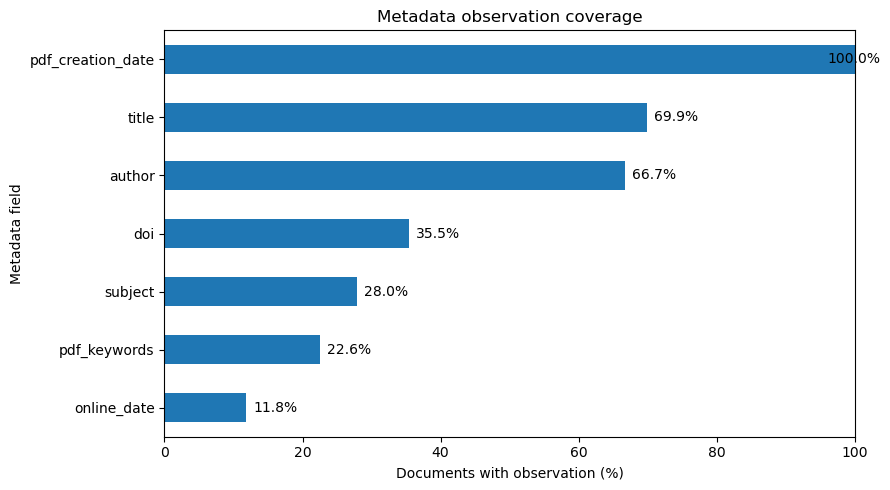

In [20]:
coverage_plot = (
    observation_coverage['coverage_percentage']
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

coverage_plot.plot(
    kind='barh',
    ax=ax
)

ax.set_title('Metadata observation coverage')
ax.set_xlabel('Documents with observation (%)')
ax.set_ylabel('Metadata field')
ax.set_xlim(0, 100)

for i, value in enumerate(coverage_plot):
    ax.text(
        min(value + 1, 96),
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()

The results show that metadata availability varies considerably by field.

PDF creation dates are available for all documents, while title and author
observations cover approximately two-thirds of the collection. DOI, subject,
PDF keywords, and online-date observations have substantially lower coverage.

This indicates that metadata has been collected for many documents, but the
amount of available metadata differs considerably between fields.

## Text extraction completeness

Data quality also depends on how successfully text was extracted from the
PDF collection.

For each document, the percentage of pages without extracted text is
calculated. Using a percentage rather than a raw page count allows documents
of different lengths to be compared fairly.

A value close to 0% indicates that text was extracted from almost all pages,
while higher percentages indicate documents that may require further
inspection or OCR.

In [21]:
text_status_summary = (
    documents['text_status']
    .value_counts()
    .rename('documents')
    .to_frame()
)

text_status_summary['percentage'] = (
    text_status_summary['documents']
    / len(documents)
    * 100
)

display(text_status_summary)

,documents,percentage
text_status,,
extractable,85,91.40
partial,7,7.53
no_text,1,1.08


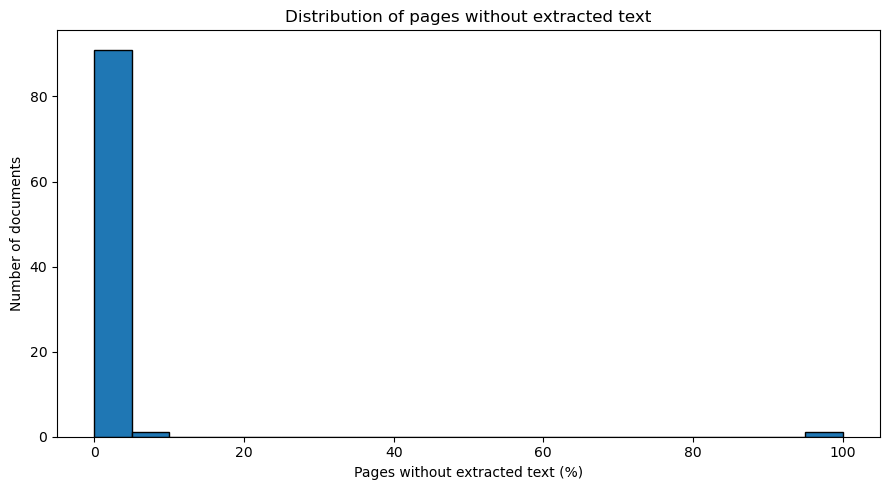

In [22]:
documents_quality = documents.copy()

documents_quality['page_count_numeric'] = pd.to_numeric(
    documents_quality['page_count'],
    errors='coerce'
)

documents_quality['pages_without_text_numeric'] = pd.to_numeric(
    documents_quality['pages_without_text'],
    errors='coerce'
)

documents_quality['missing_text_pct'] = (
    documents_quality['pages_without_text_numeric']
    / documents_quality['page_count_numeric']
    * 100
)

valid_text_quality = (
    documents_quality['missing_text_pct']
    .replace([float('inf'), -float('inf')], pd.NA)
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    valid_text_quality,
    bins=20,
    edgecolor='black'
)

ax.set_title('Distribution of pages without extracted text')
ax.set_xlabel('Pages without extracted text (%)')
ax.set_ylabel('Number of documents')

plt.tight_layout()
plt.show()

### Documents requiring extraction review

The table below identifies all documents where at least one page did not
produce extracted text.

The documents are ordered by the percentage of pages without extracted text,
with the most affected documents shown first. These records may require
manual inspection or OCR during data preparation.

In [23]:
documents_with_extraction_issues = (
    documents_quality[
        [
            'document_id',
            'title',
            'page_count_numeric',
            'pages_without_text_numeric',
            'missing_text_pct'
        ]
    ]
    .dropna(subset=['missing_text_pct'])
    .query('missing_text_pct > 0')
    .sort_values(
        'missing_text_pct',
        ascending=False
    )
)

display(documents_with_extraction_issues)

,document_id,title,page_count_numeric,pages_without_text_numeric,missing_text_pct
54,doc_c9cb81e6840debfe,,1,1,100.00
77,doc_bc8bbe9ade9d90ce,,17,1,5.88
73,doc_e958c866d4f26af7,,110,5,4.55
74,doc_37f27510898678b8,,22,1,4.55
75,doc_ca208f1f41d5e653,,22,1,4.55
76,doc_72a296a096873395,,23,1,4.35
82,doc_163340e8c4602662,,24,1,4.17
72,doc_9a5e89bf2cb67276,,103,3,2.91


## Final assessment

The automated checks indicate that the inventory has good structural
integrity. No completely duplicated rows, duplicate document identifiers,
missing document identifiers, invalid numeric values, negative numeric
values, broken table relationships, or impossible page-count relationships
were detected.

Metadata completeness is currently the main limitation of the document-level
dataset. The reviewed fields for title, DOI, publication year, publication
date, online date, document type, and language are empty for all 93
documents. However, all documents are currently marked as `unreviewed`.
The absence of values in these reviewed fields should therefore not be
interpreted as evidence that the metadata is unavailable. Metadata candidates
are stored separately in the metadata observations table and should be
reviewed before the document-level metadata is considered complete.

Text extraction quality is generally strong but not perfect. Of the 93
documents, 85 are classified as extractable, seven as partial, and one as
having no extracted text. The document with no extracted text, together with
documents showing partial extraction, should be reviewed to determine whether
OCR or manual inspection is required.

Overall, the collection appears structurally consistent, while the main
remaining quality concerns relate to metadata review and a small number of
text-extraction problems. These issues should be addressed during the next
data-preparation stage before relying on the metadata for downstream analysis.